# Previsão de Câncer de Mama usando KNN

Nesse notebook, vou usar o KNN pra classificar dados de câncer de mama (benigno ou maligno).
Vou importar os dados do próprio scikit-learn, dar uma olhada neles, preparar e treinar o modelo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

sns.set_theme(style="whitegrid")


## 1. Conhecendo a base de dados
Vou puxar os dados e ver o tamanho da base e quais são as features (as variáveis que vou usar pra prever).


In [2]:
dados = load_breast_cancer()

print(f"Total de linhas e colunas: {dados.data.shape}")
print(f"Features: {dados.feature_names[:5]} ... (são 30 no total)\n")
print(f"Classes: {dados.target_names} (onde 0 é maligno e 1 é benigno)")

df = pd.DataFrame(dados.data, columns=dados.feature_names)
df['alvo'] = dados.target
df['classe'] = df['alvo'].map({0: 'Maligno', 1: 'Benigno'})

df.head()


Total de linhas e colunas: (569, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ... (são 30 no total)

Classes: ['malignant' 'benign'] (onde 0 é maligno e 1 é benigno)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,alvo,classe
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Maligno


## 2. Dando uma olhada nos dados (EDA)


C:\Users\Roky\AppData\Local\Temp\ipykernel_12884\1423450182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classe', palette='pastel')


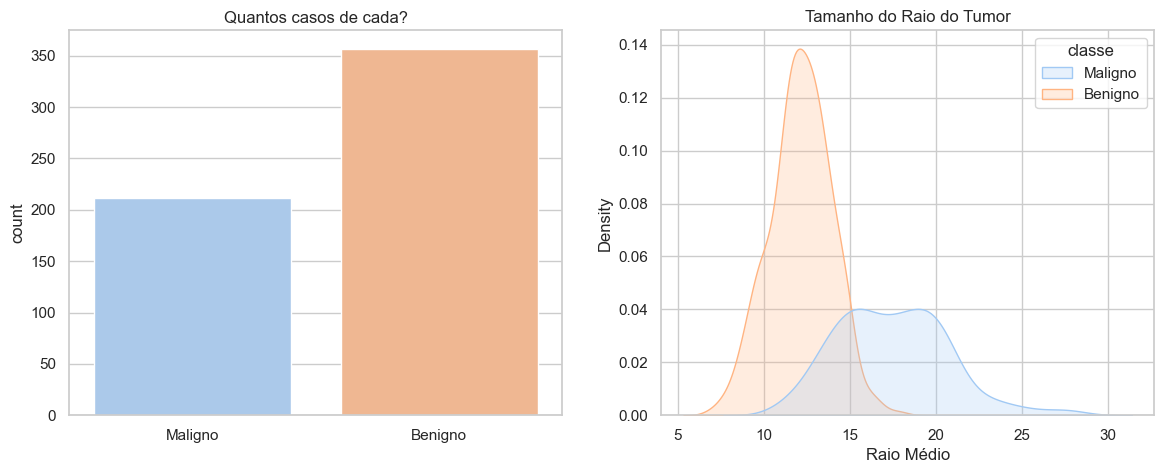

In [3]:
plt.figure(figsize=(14, 5))

# gráfico 1: proporção das classes
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='classe', palette='pastel')
plt.title('Quantos casos de cada?')
plt.xlabel('')

# gráfico 2: olhando o tamanho médio do tumor por classe
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='mean radius', hue='classe', fill=True, palette='pastel')
plt.title('Tamanho do Raio do Tumor')
plt.xlabel('Raio Médio')

plt.show()


## 3. Preparando os dados (StandardScaler)
O KNN calcula distâncias entre os pontos. Se uma variável tem valores de 1 a 10 e outra vai de 1000 a 5000, a maior vai "engolir" a menor. O `StandardScaler` resolve isso, deixando todo mundo na mesma escala (média 0 e desvio 1).


In [4]:
# separando o que é variável (X) do que é a nossa resposta (y)
X = df.drop(['alvo', 'classe'], axis=1)
y = df['alvo']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_treino_padrao = scaler.fit_transform(X_treino)
X_teste_padrao = scaler.transform(X_teste) 

print("Dados padronizados com sucesso!")


Dados padronizados com sucesso!


## 4. Treinando o modelo e testando vários 'Ks'


In [5]:
resultados = []
valores_k = range(1, 21)

# testando cada K e salvando a acurácia
for k in valores_k:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_treino_padrao, y_treino)
    
    previsoes = modelo_knn.predict(X_teste_padrao)
    acuracia = accuracy_score(y_teste, previsoes)
    resultados.append(acuracia)

# tabelinha
df_resultados = pd.DataFrame({'K': valores_k, 'Acurácia': resultados})
df_resultados.head()


,K,Acurácia
0,1,0.938596
1,2,0.938596
2,3,0.947368
3,4,0.956140
4,5,0.947368


## 5. Escolhendo o melhor K
Vou plotar isso num gráfico pra visualizar melhor onde a acurácia é mais alta.


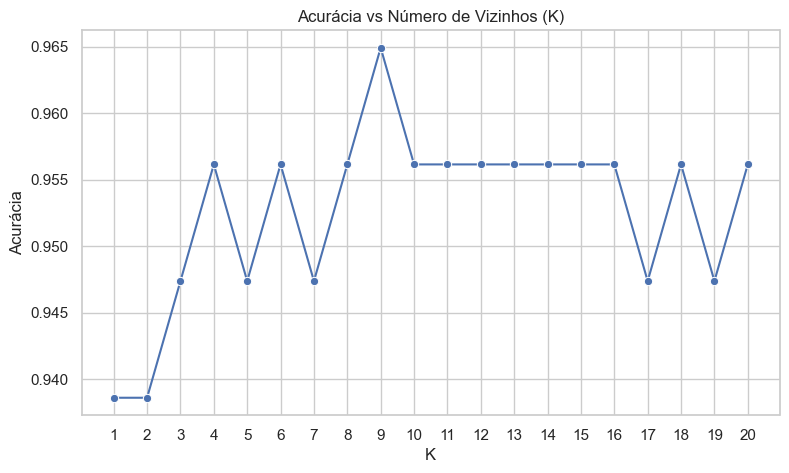

O melhor resultado foi com K = 9


In [6]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=df_resultados, x='K', y='Acurácia', marker='o')
plt.title('Acurácia vs Número de Vizinhos (K)')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

melhor_k = df_resultados.loc[df_resultados['Acurácia'].idxmax()]['K']
print(f"O melhor resultado foi com K = {int(melhor_k)}")


**Por que esse K?**
Olhando o gráfico, a gente pega o ponto mais alto. Se pegar um K muito baixo (tipo 1), o modelo decora os dados de treino e erra no teste (overfitting). Se pegar muito alto, ele fica muito genérico e erra também (underfitting).


## 6. Modelo Final e Relatório
Agora vou criar o modelo de vez usando o melhor K e ver o relatório completo de como ele se saiu no teste.


In [7]:
# treinando 
modelo_final = KNeighborsClassifier(n_neighbors=int(melhor_k))
modelo_final.fit(X_treino_padrao, y_treino)

previsoes_finais = modelo_final.predict(X_teste_padrao)

# mostrando as métricas de acerto, precisão, etc
print("--- Resultado Final ---\n")
print(classification_report(y_teste, previsoes_finais, target_names=dados.target_names))


--- Resultado Final ---

              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        43
      benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

